1. Create a Python script that loads a sample image (use any image of your favorite cricketer or celebrity), converts it to a NumPy array, and prints the array shape to demonstrate how images are represented for CNNs.


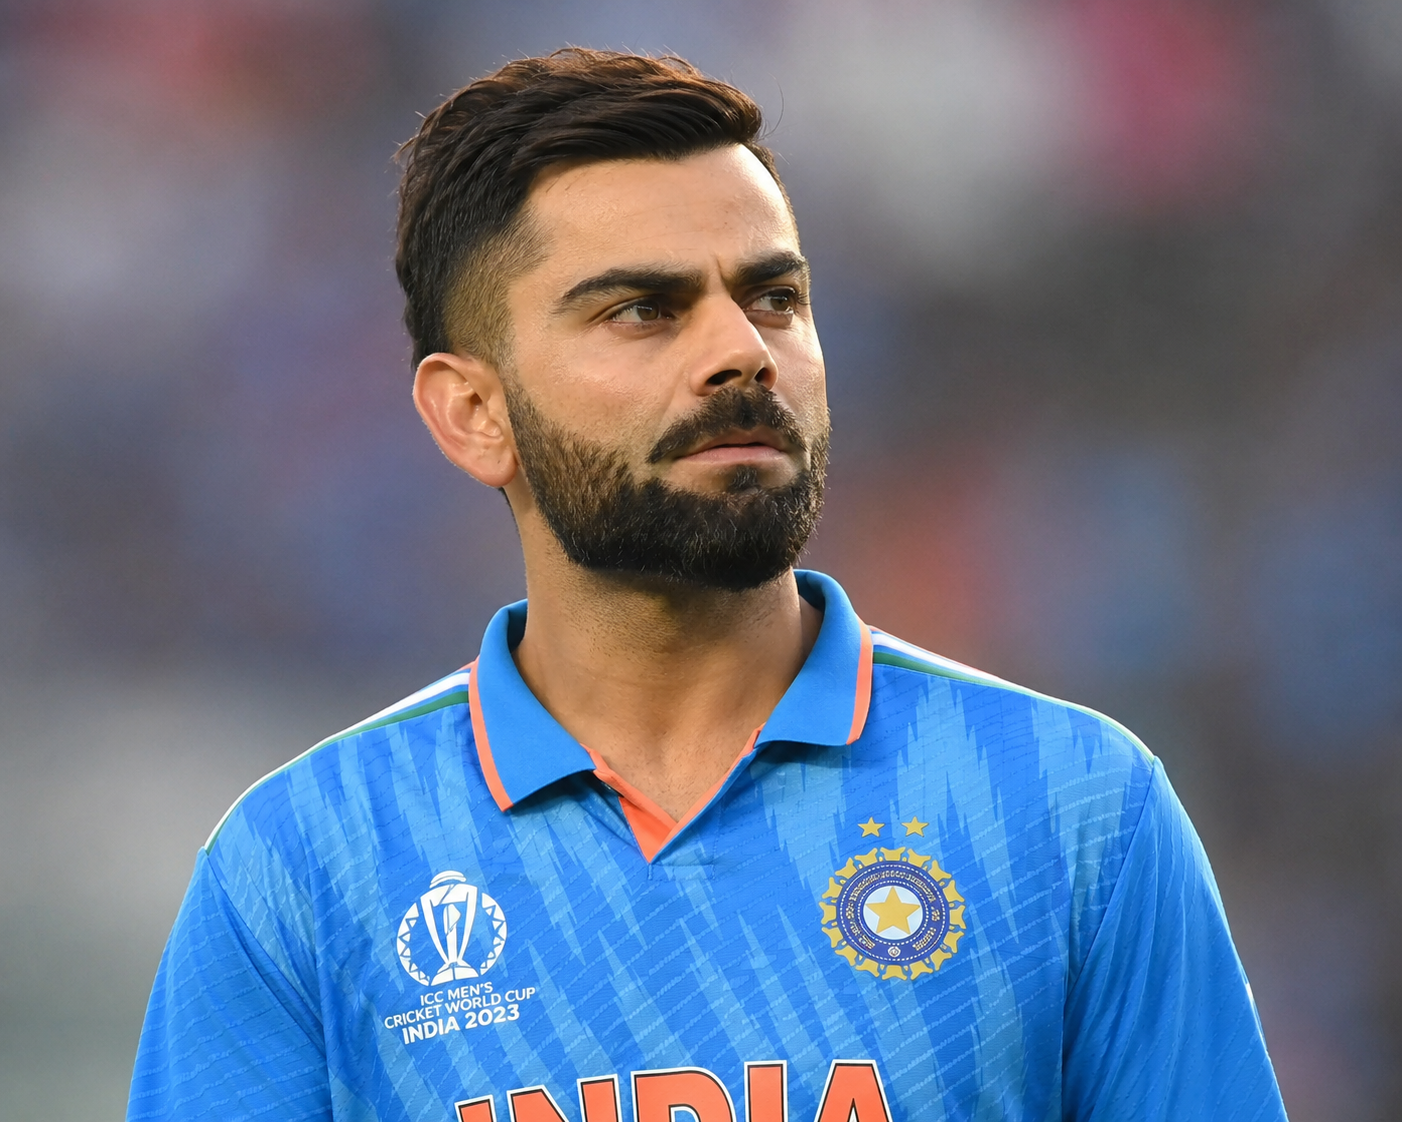

In [5]:
from PIL import Image
import numpy as np

image = Image.open("cricketer.png")

image 

In [6]:
image_array = np.array(image)

print("Image Shape:", image_array.shape)
print("Data Type:", image_array.dtype)

Image Shape: (1122, 1402, 3)
Data Type: uint8


2. Implement a simple 2D convolution operation in Python using NumPy: given a 5x5 grayscale image array and a 3x3 filter, compute the output feature map without using any deep learning libraries.<br><br><em><strong>Hint:</strong> Use nested loops to slide the filter over the image and sum the element-wise products.</em>


In [7]:
import numpy as np

image = np.array([
    [1, 2, 3, 0, 1],
    [4, 5, 6, 1, 2],
    [7, 8, 9, 2, 3],
    [1, 2, 3, 4, 5],
    [6, 7, 8, 9, 0]
])

filter_kernel = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
])

image_height, image_width = image.shape
filter_size = filter_kernel.shape[0]

output_height = image_height - filter_size + 1
output_width = image_width - filter_size + 1

feature_map = np.zeros((output_height, output_width))

for i in range(output_height):
    for j in range(output_width):
        region = image[i:i+filter_size, j:j+filter_size]
        feature_map[i, j] = np.sum(region * filter_kernel)

print("Input Image:")
print(image)

print("\nFilter:")
print(filter_kernel)

print("\nOutput Feature Map:")
print(feature_map)

Input Image:
[[1 2 3 0 1]
 [4 5 6 1 2]
 [7 8 9 2 3]
 [1 2 3 4 5]
 [6 7 8 9 0]]

Filter:
[[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]

Output Feature Map:
[[-6. 12. 12.]
 [-6.  8.  8.]
 [-6.  2. 12.]]


3. Draw the architecture diagram of a basic CNN (on paper or using a tool like draw.io) showing input layer, one convolutional layer, one pooling layer, and an output layer. Label each part and briefly describe its function in 1-2 lines.


+------------------+
|   Input Layer    |
|   28 x 28 Image  |
+------------------+
          |
          v
+------------------+
| Convolution Layer|
|   3x3 Filters    |
| Feature Maps     |
+------------------+
          |
          v
+------------------+
|  Pooling Layer   |
|   Max Pool 2x2   |
| Reduce Size      |
+------------------+
          |
          v
+------------------+
|   Output Layer   |
| Class Prediction |
| (e.g., Cat/Dog)  |
+------------------+

| Layer                 | Function                                                                                                                    |
| --------------------- | --------------------------------------------------------------------------------------------------------------------------- |
| **Input Layer**       | Receives the original image as pixel values. For example, a grayscale image may be represented as a 28×28 matrix.           |
| **Convolution Layer** | Applies filters (kernels) to detect features such as edges, textures, and patterns, producing feature maps.                 |
| **Pooling Layer**     | Reduces the spatial size of feature maps (e.g., using Max Pooling), decreasing computation and helping prevent overfitting. |
| **Output Layer**      | Produces the final prediction or classification result, such as identifying whether an image contains a cat, dog, or digit. |


4. Write a function in Python that takes an image array and returns a new array where each pixel is replaced by the maximum value in its 2x2 local neighborhood (simulate max pooling).<br><br><em><strong>Constraint:</strong> Do not use any deep learning libraries like TensorFlow or PyTorch for this task.</em>

In [8]:
import numpy as np

def max_pooling(image):
    rows, cols = image.shape

    output_rows = rows // 2
    output_cols = cols // 2

    pooled = np.zeros((output_rows, output_cols), dtype=image.dtype)

    for i in range(output_rows):
        for j in range(output_cols):
            region = image[i*2:(i*2)+2, j*2:(j*2)+2]
            pooled[i, j] = np.max(region)

    return pooled

image = np.array([
    [1, 3, 2, 4],
    [5, 6, 1, 2],
    [7, 2, 8, 1],
    [0, 9, 3, 5]
])

pooled_image = max_pooling(image)

print("Original Image:")
print(image)

print("\nPooled Image:")
print(pooled_image)

Original Image:
[[1 3 2 4]
 [5 6 1 2]
 [7 2 8 1]
 [0 9 3 5]]

Pooled Image:
[[6 4]
 [9 8]]


5. Explain with a real-world example from Instagram or Zomato how translation invariance in CNNs is useful. Write 2-3 sentences connecting it to how these apps recognize faces or food items even if they appear in different positions in the image.

Translation invariance allows a CNN to recognize the same object even when it appears in different locations within an image.

For example, on Instagram, a face-recognition system can identify a person's face whether it is in the center, corner, or top of a photo. Similarly, on Zomato, a CNN can recognize a pizza or burger in a food image even if the food item is positioned differently in each picture. This makes image recognition more robust and accurate in real-world applications.